
<div align="center">
  <h1>🧠 Recurrent Neural Networks: From Intuition to Implementation</h1>
  <h3>USRF Workshop · Amity Centre for Artificial Intelligence (ACAI), Amity University Noida</h3>
  <p><b>Instructor:</b> Dr. Nihal Kumar &nbsp;|&nbsp; <b>Date:</b> June 2026</p>
  <hr/>
</div>

> **Notebook compatibility:** Runs on **Kaggle · Google Colab · Jupyter (local / DGX)**  
> All datasets download at runtime - no manual steps needed.  
> **Framework: PyTorch only** (no TensorFlow / Keras used for modelling).  
> GPU is auto-detected and strongly recommended.

---
## 📋 Contents

| # | Section |
|---|---------|
| 0 | Environment Setup, Imports & GPU Check |
| 1 | Why Sequential Modeling? |
| 2 | From ANN to RNN - Building Intuition |
| 3 | Vanilla RNN: Forward Pass & BPTT from Scratch (pure PyTorch) |
| 4 | **Hands-On 1** - Sentiment Analysis with Vanilla RNN (IMDB) |
| 5 | Vanishing / Exploding Gradients - Visualised |
| 6 | LSTM - Gates, Cell State & Gradient Flow |
| 7 | **Hands-On 2** - Stock Price Prediction with LSTM (Yahoo Finance) |
| 8 | GRU - Simpler but Powerful |
| 9 | Sequence-to-Sequence + Attention (Encoder-Decoder) |
| 10 | **Hands-On 3** - Text Generation with LSTM (Shakespeare) |
| 11 | Tasks |


---
## 🔧 Section 0 · Environment Setup, Imports & GPU Check

This cell auto-detects the platform (Kaggle / Colab / Local) and installs any missing packages.  
`torchinfo` is used throughout the notebook to print a clean, layer-by-layer model summary  
(input/output shapes, parameter counts, FLOPs) - much more informative than `print(model)`.


### 0.1 - Platform Detection & Package Installation

In [2]:
import sys, os

# ── Platform detection ────────────────────────────────────────
def detect_platform():
    if 'google.colab' in sys.modules:
        return 'colab'
    if os.path.exists('/kaggle'):
        return 'kaggle'
    return 'local'

PLATFORM = detect_platform()
print(f"Running on: {PLATFORM.upper()}")

# ── Install torchinfo (works everywhere) ──────────────────────
os.system("pip install -q torchinfo yfinance 2>/dev/null")
print("torchinfo & yfinance ready ✓")


Running on: KAGGLE
torchinfo & yfinance ready ✓


### 0.2 - Core Imports (PyTorch only)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch     
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from torchinfo import summary as torchinfo_summary     

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"NumPy    : {np.__version__}")

import torchinfo
print(f"torchinfo: {torchinfo.__version__}")


PyTorch  : 2.10.0+cu128
NumPy    : 2.4.6
torchinfo: 1.8.0


### 0.3 - GPU / Device Check

In [4]:
def get_device():
    if torch.cuda.is_available():
        device    = torch.device('cuda')
        gpu_name  = torch.cuda.get_device_name(0)
        mem_total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"✅  GPU  : {gpu_name}")
        print(f"    VRAM : {mem_total:.1f} GB")
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
        print("✅  Apple MPS (Metal) detected")
    else:
        device = torch.device('cpu')
        print("⚠️  No GPU - running on CPU (training will be slower)")
    return device

DEVICE = get_device()
print(f"\nActive device -> {DEVICE}")


✅  GPU  : Tesla T4
    VRAM : 15.6 GB

Active device -> cuda


---
## 📌 Section 1 · Why Sequential Modeling?

> *"Given a Football Image - Can you predict where it will go next?"*

Seeing a single frame gives no information. Once you see the **player's kicking direction** - i.e., the **sequence of events** - prediction becomes possible.

### Sequence data is everywhere

| Task | Input | Output |
|------|-------|--------|
| Speech recognition | Audio waveform $\mathbf{x}_{1:T}$ | Text transcript |
| Machine translation | English sentence | French sentence |
| Sentiment analysis | Movie review | Positive / Negative |
| Stock prediction | Past $T$ closing prices | Next-day price |
| DNA analysis | Nucleotide string $\{A,T,G,C\}^T$ | Functional annotation |

### Why ANN/CNN cannot handle sequences

1. **Fixed input size** - a CNN always expects a tensor of shape $C \times H \times W$; a sentence can have $5$ or $500$ tokens.
2. **Fixed output size** - a classifier outputs $k$ class probabilities; a translator must produce a variable-length sequence.
3. **No parameter sharing** - position $1$ and position $5$ in a sentence use **completely different** weight matrices in a plain ANN.
4. **No temporal memory** - consider *"I grew up in Spain… I speak fluent* ***Spanish****"*. A CNN sees each frame in isolation and cannot connect information across a long gap.

$\Rightarrow$ We need **Recurrent Neural Networks**.


#### Demonstrating the variable-length problem

In [5]:
# ── Why padding/truncation is a hack, not a solution ──────────
sentences = [
    "I love this movie",
    "The cinematography, acting, direction and screenplay were all absolutely phenomenal",
    "Bad",
]

print("Word-level token counts for three reviews:\n")
for s in sentences:
    tokens = s.split()
    print(f"  Tokens: {len(tokens):3d}  |  '{s[:55]}...'")

print("\n-> A fixed-input ANN would need aggressive padding/truncation.")
print("-> An RNN processes each token one step at a time - length is irrelevant.")


Word-level token counts for three reviews:

  Tokens:   4  |  'I love this movie...'
  Tokens:  10  |  'The cinematography, acting, direction and screenplay we...'
  Tokens:   1  |  'Bad...'

-> A fixed-input ANN would need aggressive padding/truncation.
-> An RNN processes each token one step at a time - length is irrelevant.


---
## 🔁 Section 2 · From ANN to RNN - Building Intuition

### The Recurrence Formula

At every time step $t$, an RNN computes:

$$h_t = f_W\!\left(h_{t-1},\, x_t\right)$$

where:
- $x_t \in \mathbb{R}^{d}$ - input token / feature vector at step $t$
- $h_{t-1} \in \mathbb{R}^{h}$ - hidden state from the **previous** step (the "memory")
- $f_W$ - **same function with the same weights** at every step <- the key innovation

Expanding this into matrix form:

$$\boxed{h_t = \tanh\!\left(W_{hh}\, h_{t-1} + W_{xh}\, x_t + b_h\right)}$$

$$y_t = W_{hy}\, h_t + b_y$$

> **Parameter sharing:** $W_{hh}$, $W_{xh}$, $b_h$ are the **same matrices** at every time step.  
> This is why the number of parameters does *not* grow with sequence length.

### RNN Architectures

| Architecture | Shape | Example application |
|---|---|---|
| **one -> one** | $x \to y$ | Image classification |
| **one -> many** | $x \to y_{1:T}$ | Image captioning |
| **many -> one** | $x_{1:T} \to y$ | Sentiment analysis |
| **many -> many (sync)** | $x_{1:T} \to y_{1:T}$ | Named entity recognition |
| **many -> many (async)** | $x_{1:S} \to y_{1:T}$ | Machine translation (encoder-decoder) |


#### Visualising an Unrolled RNN Across Time Steps

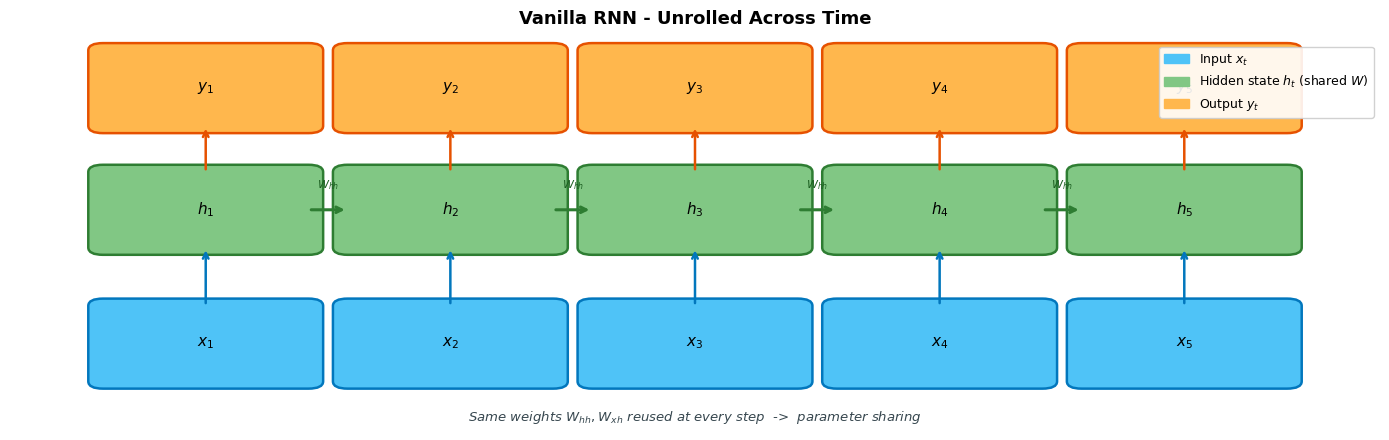

In [6]:
# ── Unrolled RNN diagram - uses matplotlib.patches.FancyBboxPatch ─
from matplotlib.patches import FancyBboxPatch  # explicit (not plt.FancyBboxPatch)

def draw_rnn_unrolled(T=5, title="Vanilla RNN - Unrolled Across Time"):
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.set_xlim(-0.3, T + 0.3)
    ax.set_ylim(-0.4, 2.8)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

    C = {'x': '#4FC3F7', 'h': '#81C784', 'y': '#FFB74D'}

    for t in range(T):
        # Input x_t
        ax.add_patch(FancyBboxPatch((t+0.08, 0.0), 0.84, 0.62,
            boxstyle="round,pad=0.06", fc=C['x'], ec='#0277BD', lw=1.8))
        ax.text(t+0.5, 0.31, f'$x_{{{t+1}}}$', ha='center', va='center',
                fontsize=11, fontweight='bold')

        # Hidden h_t
        ax.add_patch(FancyBboxPatch((t+0.08, 1.1), 0.84, 0.62,
            boxstyle="round,pad=0.06", fc=C['h'], ec='#2E7D32', lw=1.8))
        ax.text(t+0.5, 1.41, f'$h_{{{t+1}}}$', ha='center', va='center',
                fontsize=11, fontweight='bold')

        # Output y_t
        ax.add_patch(FancyBboxPatch((t+0.08, 2.1), 0.84, 0.62,
            boxstyle="round,pad=0.06", fc=C['y'], ec='#E65100', lw=1.8))
        ax.text(t+0.5, 2.41, f'$y_{{{t+1}}}$', ha='center', va='center',
                fontsize=11, fontweight='bold')

        # x -> h
        ax.annotate('', xy=(t+0.5, 1.1), xytext=(t+0.5, 0.62),
                    arrowprops=dict(arrowstyle='->', color='#0277BD', lw=1.8))
        # h -> y
        ax.annotate('', xy=(t+0.5, 2.1), xytext=(t+0.5, 1.72),
                    arrowprops=dict(arrowstyle='->', color='#E65100', lw=1.8))
        # Recurrent h_t -> h_{t+1}
        if t < T - 1:
            ax.annotate('', xy=(t+1.08, 1.41), xytext=(t+0.92, 1.41),
                        arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2.2))
            ax.text(t+1.0, 1.56, r'$W_{hh}$', ha='center', va='bottom',
                    fontsize=8, color='#1B5E20')

    # Shared weights label
    ax.text(T/2, -0.3, r'Same weights $W_{hh}, W_{xh}$ reused at every step  ->  parameter sharing',
            ha='center', va='center', fontsize=9.5, color='#37474F',
            style='italic')

    legend_handles = [
        mpatches.Patch(color=C['x'], label='Input $x_t$'),
        mpatches.Patch(color=C['h'], label='Hidden state $h_t$ (shared $W$)'),
        mpatches.Patch(color=C['y'], label='Output $y_t$'),
    ]
    ax.legend(handles=legend_handles, loc='upper right', fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()

draw_rnn_unrolled(T=5)


---
## 🛠️ Section 3 · Vanilla RNN - Forward Pass & BPTT from Scratch (Pure PyTorch)

Before using `nn.RNN`, we **hand-build** a single RNN cell so every matrix multiplication is visible.  
This is the direct code translation of the forward-propagation slides.

### Equations (recap)

$$h_t = \tanh\!\left(\underbrace{W_{hh}}_{\text{recurrent}} h_{t-1} + \underbrace{W_{xh}}_{\text{input}} x_t + b_h\right)$$

$$y_t = W_{hy}\, h_t + b_y$$

### BPTT (Back-Propagation Through Time)

The gradient of the total loss $\mathcal{L} = \sum_t \mathcal{L}_t$ with respect to $W_{hh}$ requires  
summing contributions **across all time steps**:

$$\frac{\partial \mathcal{L}}{\partial W_{hh}} = \sum_{t=1}^{T} \frac{\partial \mathcal{L}_t}{\partial W_{hh}}
= \sum_{t=1}^{T} \sum_{k=1}^{t} \frac{\partial \mathcal{L}_t}{\partial h_t}
\left(\prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}}\right)
\frac{\partial h_k}{\partial W_{hh}}$$

Each $\frac{\partial h_j}{\partial h_{j-1}} = W_{hh}^{\top} \operatorname{diag}\!\left(1 - h_j^2\right)$ - this repeated product is what causes **vanishing / exploding gradients** (Section 5).


#### 3.1 - RNN Cell (pure PyTorch `nn.Parameter`)

In [7]:
class VanillaRNNCell(nn.Module):
    '''
    One RNN cell:
        h_t = tanh(W_hh @ h_{t-1}  +  W_xh @ x_t  +  b_h)
        y_t = W_hy @ h_t + b_y

    Built with bare nn.Parameter - no nn.Linear shortcuts - so every
    matrix multiply is explicit and educational.
    '''
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super().__init__()
        k = hidden_size ** -0.5                     # Kaiming-uniform scale
        self.W_xh = nn.Parameter(torch.empty(hidden_size, input_size).uniform_(-k, k))
        self.W_hh = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(-k, k))
        self.b_h  = nn.Parameter(torch.zeros(hidden_size))
        self.W_hy = nn.Parameter(torch.empty(output_size, hidden_size).uniform_(-k, k))
        self.b_y  = nn.Parameter(torch.zeros(output_size))

        self.hidden_size = hidden_size

    def step(self, x: torch.Tensor, h_prev: torch.Tensor):
        '''Single time-step forward.
        x      : (batch, input_size)
        h_prev : (batch, hidden_size)
        '''
        h = torch.tanh(x @ self.W_xh.T + h_prev @ self.W_hh.T + self.b_h)
        y = h @ self.W_hy.T + self.b_y
        return h, y

    def forward(self, x_seq: torch.Tensor, h0: torch.Tensor = None):
        '''
        x_seq : (batch, T, input_size)
        returns hs (T hidden states), ys (T outputs)
        '''
        batch, T, _ = x_seq.shape
        h = h0 if h0 is not None else torch.zeros(batch, self.hidden_size, device=x_seq.device)
        hs, ys = [], []
        for t in range(T):
            h, y = self.step(x_seq[:, t, :], h)
            hs.append(h); ys.append(y)
        return torch.stack(hs, dim=1), torch.stack(ys, dim=1)   # both (batch, T, size)


# ── Quick shape check ─────────────────────────────────────────
INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE = 10, 32, 5
BATCH_SIZE, T_STEPS = 4, 6

rnn_scratch = VanillaRNNCell(INPUT_SIZE, HIDDEN_SIZE, OUTPUT_SIZE).to(DEVICE)
x_dummy = torch.randn(BATCH_SIZE, T_STEPS, INPUT_SIZE, device=DEVICE)
hs, ys  = rnn_scratch(x_dummy)

print("Manual RNN Cell - forward pass")
print(f"  Input  : {x_dummy.shape}  ->  (batch, T, input_size)")
print(f"  Hidden : {hs.shape}       ->  (batch, T, hidden_size)")
print(f"  Output : {ys.shape}       ->  (batch, T, output_size)")


Manual RNN Cell - forward pass
  Input  : torch.Size([4, 6, 10])  ->  (batch, T, input_size)
  Hidden : torch.Size([4, 6, 32])       ->  (batch, T, hidden_size)
  Output : torch.Size([4, 6, 5])       ->  (batch, T, output_size)


#### 3.2 - `torchinfo` Model Summary

In [8]:
# torchinfo needs a single input; we pass a (batch, T, input_size) tensor
print("=" * 65)
print("torchinfo summary - VanillaRNNCell")
print("=" * 65)
torchinfo_summary(
    rnn_scratch,
    input_size=(BATCH_SIZE, T_STEPS, INPUT_SIZE),
    device=DEVICE,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1,
)


torchinfo summary - VanillaRNNCell
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
VanillaRNNCell                           [4, 6, 10]                [4, 6, 32]                1,541                     True
Total params: 1,541
Trainable params: 1,541
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.01
Estimated Total Size (MB): 0.01


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
VanillaRNNCell                           [4, 6, 10]                [4, 6, 32]                1,541                     True
Total params: 1,541
Trainable params: 1,541
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

#### 3.3 - Hidden State Heatmap (what the RNN 'remembers')

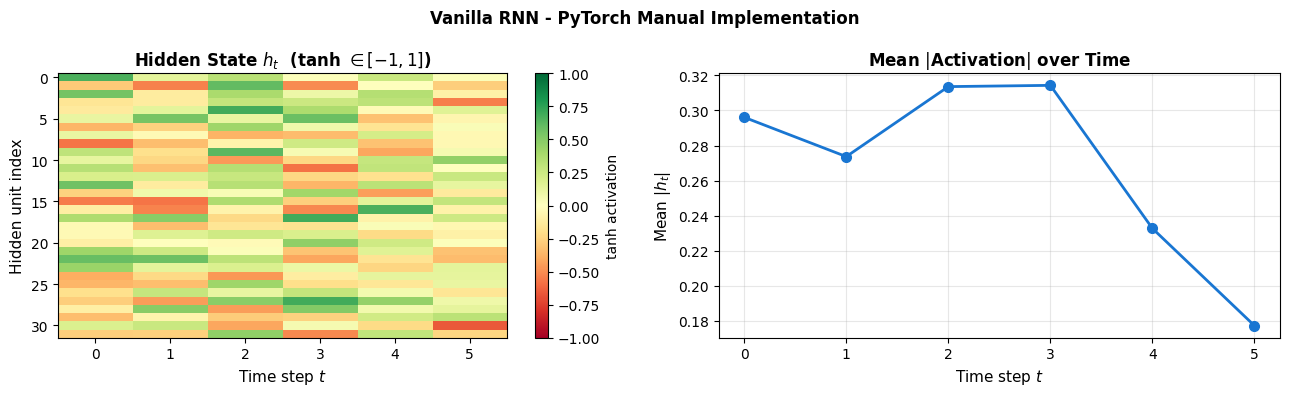

In [9]:
# Visualise activations of all hidden units across the sequence
hs_np = hs[0].detach().cpu().numpy()   # shape: (T, hidden_size) for first sample

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: heatmap - colour = tanh value in [-1, 1]
im = axes[0].imshow(hs_np.T, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[0], label='tanh activation')
axes[0].set_xlabel('Time step $t$', fontsize=11)
axes[0].set_ylabel('Hidden unit index', fontsize=11)
axes[0].set_title(r'Hidden State $h_t$  (tanh $\in [-1, 1]$)', fontweight='bold')

# Right: mean absolute activation over time
axes[1].plot(range(T_STEPS), np.abs(hs_np).mean(axis=1),
             marker='o', linewidth=2, markersize=7, color='#1976D2')
axes[1].set_xlabel('Time step $t$', fontsize=11)
axes[1].set_ylabel(r'Mean $|h_t|$', fontsize=11)
axes[1].set_xticks(range(T_STEPS))
axes[1].set_title(r'Mean $|$Activation$|$ over Time', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Vanilla RNN - PyTorch Manual Implementation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 🎬 Section 4 · Hands-On 1 - Sentiment Analysis with Vanilla RNN (IMDB)

**Dataset:** IMDB Movie Reviews - 50 000 reviews, binary label (positive / negative).  
**Task type:** many $\to$ one - read a variable-length review, output a single sentiment score.  
**Architecture:** Embedding $\to$ `nn.RNN` $\to$ Linear $\to$ Sigmoid

We load IMDB using PyTorch's built-in `torchtext` utility (`torchtext.datasets.IMDB`).  
If `torchtext` is unavailable on the platform, we fall back to a pure-PyTorch CSV download route.

### Loss function

Binary cross-entropy with logits:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log \hat{p}_i + (1 - y_i)\log(1 - \hat{p}_i)\right]$$

where $\hat{p}_i = \sigma(z_i)$ and $\sigma$ is the sigmoid function.


#### 4.1 - Load & Tokenise IMDB (pure PyTorch / torchtext)

In [10]:
# ── Pure-PyTorch IMDB loader - no Keras dependency ────────────
# Uses torchtext on Colab/Kaggle/DGX; falls back to manual download otherwise.
import re, collections

def simple_tokenise(text: str):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # strip HTML
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

# ── Download raw IMDB from Stanford (public, ~84 MB) ──────────
import urllib.request, tarfile, pathlib

IMDB_DIR = pathlib.Path('/tmp/imdb_raw')
if not IMDB_DIR.exists():
    print("Downloading IMDB dataset (~84 MB) …")
    url  = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    dest = '/tmp/aclImdb_v1.tar.gz'
    urllib.request.urlretrieve(url, dest)
    with tarfile.open(dest) as tar:
        tar.extractall('/tmp')
    IMDB_DIR.mkdir(exist_ok=True)
    print("Done.")
else:
    print("IMDB already cached.")

def load_imdb_split(split='train'):
    texts, labels = [], []
    base = pathlib.Path(f'/tmp/aclImdb/{split}')
    for label_str, label_int in [('pos', 1), ('neg', 0)]:
        for fpath in (base / label_str).glob('*.txt'):
            texts.append(fpath.read_text(encoding='utf-8'))
            labels.append(label_int)
    return texts, labels

print("Reading files …")
train_texts, train_labels = load_imdb_split('train')
test_texts,  test_labels  = load_imdb_split('test')
print(f"Train: {len(train_texts):,}  |  Test: {len(test_texts):,}")
print(f"\nSample review (first 120 chars):\n{train_texts[0][:120]}")
print(f"Label: {train_labels[0]}  (1=positive, 0=negative)")


/tmp/ipykernel_58/2329147496.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/tmp')


Done.
Reading files …
Train: 25,000  |  Test: 25,000

Sample review (first 120 chars):
The Farrelly brothers, Bobby and Peter, are at it again. With "Fever Pitch" the creators of other films that have dealt 
Label: 1  (1=positive, 0=negative)


#### 4.2 - Build Vocabulary & Pad Sequences

In [11]:
VOCAB_SIZE = 10_000
MAX_LEN    = 200

# Build vocab from training set only (no data leakage)
counter = collections.Counter()
for text in train_texts:
    counter.update(simple_tokenise(text)[:MAX_LEN])

# Special tokens: 0=PAD, 1=UNK, 2+=words
word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, _ in counter.most_common(VOCAB_SIZE - 2):
    word2idx[word] = len(word2idx)
print(f"Vocabulary size: {len(word2idx):,}")

def encode_and_pad(texts, max_len=MAX_LEN):
    result = []
    for text in texts:
        ids = [word2idx.get(w, 1) for w in simple_tokenise(text)[:max_len]]
        ids = ids + [0] * max(0, max_len - len(ids))    # right-pad
        result.append(ids)
    return torch.tensor(result, dtype=torch.long)

print("Encoding sequences …")
X_train = encode_and_pad(train_texts)
X_test  = encode_and_pad(test_texts)
y_train = torch.tensor(train_labels, dtype=torch.float)
y_test  = torch.tensor(test_labels,  dtype=torch.float)

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")

BATCH_SIZE = 128
train_ds  = TensorDataset(X_train, y_train)
test_ds   = TensorDataset(X_test,  y_test)
train_ldr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_ldr  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_ldr)}  |  Test batches: {len(test_ldr)}")


Vocabulary size: 10,000
Encoding sequences …
X_train: torch.Size([25000, 200])  |  y_train: torch.Size([25000])
Train batches: 196  |  Test batches: 196


#### 4.3 - Model: Embedding -> `nn.RNN` -> Classifier

The last hidden state $h_T$ acts as a **fixed-size summary vector** of the entire review,  
which is then projected to a single logit and passed through $\sigma$ to get $\hat{p} \in (0,1)$.


In [12]:
class SentimentRNN(nn.Module):
    '''
    Architecture:
        Embedding  ->  nn.RNN (many-to-one)  ->  Dropout  ->  Linear(1)
    The final hidden state h_T summarises the entire review.
    '''
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 n_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn       = nn.RNN(embed_dim, hidden_dim, num_layers=n_layers,
                                batch_first=True,
                                dropout=dropout if n_layers > 1 else 0.0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x : (batch, seq_len)
        emb       = self.dropout(self.embedding(x))    # (batch, seq, embed)
        _, h_last = self.rnn(emb)                      # h_last: (n_layers, batch, hidden)
        h         = self.dropout(h_last[-1])           # take top layer: (batch, hidden)
        return self.fc(h).squeeze(1)                   # (batch,)


EMBED_DIM  = 64
HIDDEN_DIM = 128

model_rnn = SentimentRNN(len(word2idx), EMBED_DIM, HIDDEN_DIM).to(DEVICE)

print("=" * 65)
print("torchinfo summary - SentimentRNN (Vanilla RNN)")
print("=" * 65)
torchinfo_summary(
    model_rnn,
    input_size=(BATCH_SIZE, MAX_LEN),
    dtypes=[torch.long],
    device=DEVICE,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1,
)


torchinfo summary - SentimentRNN (Vanilla RNN)
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
SentimentRNN                             [128, 200]                [128]                     --                        True
├─Embedding: 1-1                         [128, 200]                [128, 200, 64]            640,000                   True
├─Dropout: 1-2                           [128, 200, 64]            [128, 200, 64]            --                        --
├─RNN: 1-3                               [128, 200, 64]            [128, 200, 128]           24,832                    True
├─Dropout: 1-4                           [128, 128]                [128, 128]                --                        --
├─Linear: 1-5                            [128, 128]                [128, 1]                  129                       True
Total params: 664,961
Trainable params: 664,961
Non-trainable params: 0
Total mult-a

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
SentimentRNN                             [128, 200]                [128]                     --                        True
├─Embedding: 1-1                         [128, 200]                [128, 200, 64]            640,000                   True
├─Dropout: 1-2                           [128, 200, 64]            [128, 200, 64]            --                        --
├─RNN: 1-3                               [128, 200, 64]            [128, 200, 128]           24,832                    True
├─Dropout: 1-4                           [128, 128]                [128, 128]                --                        --
├─Linear: 1-5                            [128, 128]                [128, 1]                  129                       True
Total params: 664,961
Trainable params: 664,961
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 717.64
Input size (MB): 

#### 4.4 - Training Loop with Gradient Clipping

In [13]:
EPOCHS    = 5
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_rnn.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb   = xb.to(DEVICE), yb.to(DEVICE)
            logits   = model(xb)
            total_loss += nn.functional.binary_cross_entropy_with_logits(
                              logits, yb, reduction='sum').item()
            preds    = (torch.sigmoid(logits) > 0.5).long()
            correct += (preds == yb.long()).sum().item()
            total   += len(yb)
    return total_loss / total, correct / total

history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc']}

for epoch in range(1, EPOCHS + 1):
    model_rnn.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for xb, yb in train_ldr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits  = model_rnn(xb)
        loss    = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_rnn.parameters(), max_norm=5.0)  # gradient clipping
        optimizer.step()

        run_loss    += loss.item() * len(yb)
        preds        = (torch.sigmoid(logits) > 0.5).long()
        run_correct += (preds == yb.long()).sum().item()
        run_total   += len(yb)

    scheduler.step()
    tr_loss = run_loss / run_total
    tr_acc  = run_correct / run_total
    vl_loss, vl_acc = evaluate(model_rnn, test_ldr)

    for k, v in zip(['train_loss','val_loss','train_acc','val_acc'],
                    [tr_loss, vl_loss, tr_acc, vl_acc]):
        history[k].append(v)

    print(f"Epoch [{epoch}/{EPOCHS}]  "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%  |  "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}%")


Epoch [1/5]  Train Loss: 0.6964  Acc: 50.57%  |  Val Loss: 0.6959  Acc: 50.45%
Epoch [2/5]  Train Loss: 0.6937  Acc: 50.88%  |  Val Loss: 0.6934  Acc: 50.87%
Epoch [3/5]  Train Loss: 0.6893  Acc: 51.94%  |  Val Loss: 0.6946  Acc: 50.60%
Epoch [4/5]  Train Loss: 0.6875  Acc: 52.94%  |  Val Loss: 0.6945  Acc: 50.58%
Epoch [5/5]  Train Loss: 0.6847  Acc: 54.05%  |  Val Loss: 0.6748  Acc: 59.88%


#### 4.5 - Training Curves

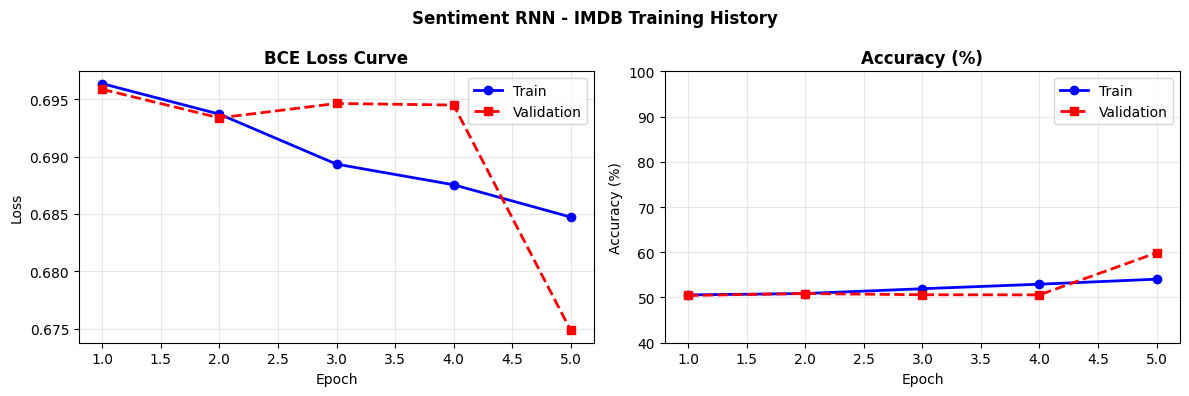

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, EPOCHS + 1)

ax1.plot(ep, history['train_loss'], 'b-o', label='Train', linewidth=2)
ax1.plot(ep, history['val_loss'],   'r--s', label='Validation', linewidth=2)
ax1.set_title('BCE Loss Curve', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, [a*100 for a in history['train_acc']], 'b-o', label='Train', linewidth=2)
ax2.plot(ep, [a*100 for a in history['val_acc']],   'r--s', label='Validation', linewidth=2)
ax2.set_title('Accuracy (%)', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim(40, 100); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Sentiment RNN - IMDB Training History', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


#### 4.6 - Inference on Custom Text

In [16]:
def predict_sentiment(review: str):
    model_rnn.eval()
    ids = [word2idx.get(w, 1) for w in simple_tokenise(review)[:MAX_LEN]]
    ids = ids + [0] * max(0, MAX_LEN - len(ids))
    t   = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(model_rnn(t)).item()
    label = "POSITIVE 😊" if prob > 0.5 else "NEGATIVE 😔"
    print(f"Review   : {review[:70]}")
    print(f"P(pos)   : {prob:.4f}")
    print(f"Sentiment: {label}\n")

predict_sentiment("This movie was absolutely brilliant and deeply moving")
predict_sentiment("Terrible film. Complete waste of time. Boring and predictable.")
predict_sentiment("The cinematography was great but the story dragged on forever")


Review   : This movie was absolutely brilliant and deeply moving
P(pos)   : 0.4138
Sentiment: NEGATIVE 😔

Review   : Terrible film. Complete waste of time. Boring and predictable.
P(pos)   : 0.4138
Sentiment: NEGATIVE 😔

Review   : The cinematography was great but the story dragged on forever
P(pos)   : 0.6305
Sentiment: POSITIVE 😊



---
## ⚠️ Section 5 · Vanishing and Exploding Gradients

### Why it happens - the math

During BPTT the gradient of $\mathcal{L}$ w.r.t. $W_{hh}$ contains a chain of Jacobians:

$$\frac{\partial h_t}{\partial h_k} = \prod_{j=k+1}^{t} \underbrace{W_{hh}^{\top} \operatorname{diag}\!\left(1 - h_j^2\right)}_{\text{Jacobian at step } j}$$

Let $\lambda$ be the **spectral radius** (largest singular value) of $W_{hh}$:

| Condition | Effect over $T$ steps |
|-----------|----------------------|
| $\lambda < 1$ | $\lambda^T \to 0$ - **vanishing gradient** |
| $\lambda > 1$ | $\lambda^T \to \infty$ - **exploding gradient** |

### Solutions (from the slides)

| Problem | Fix |
|---------|-----|
| Exploding gradient | **Gradient clipping**: $g \leftarrow g \cdot \frac{\tau}{\max(\|g\|, \tau)}$ |
| Vanishing gradient | ReLU activation, identity initialisation, **LSTM / GRU gated cells** |


#### 5.1 - Simulate Gradient Magnitude Over Backprop Steps

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_58/902663448.py:12: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(simulate_gradient(sr, T), label=f'$\lambda$={sr}',
/tmp/ipykernel_58/902663448.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax2.plot(simulate_gradient(sr, T), label=f'$\lambda$={sr}',


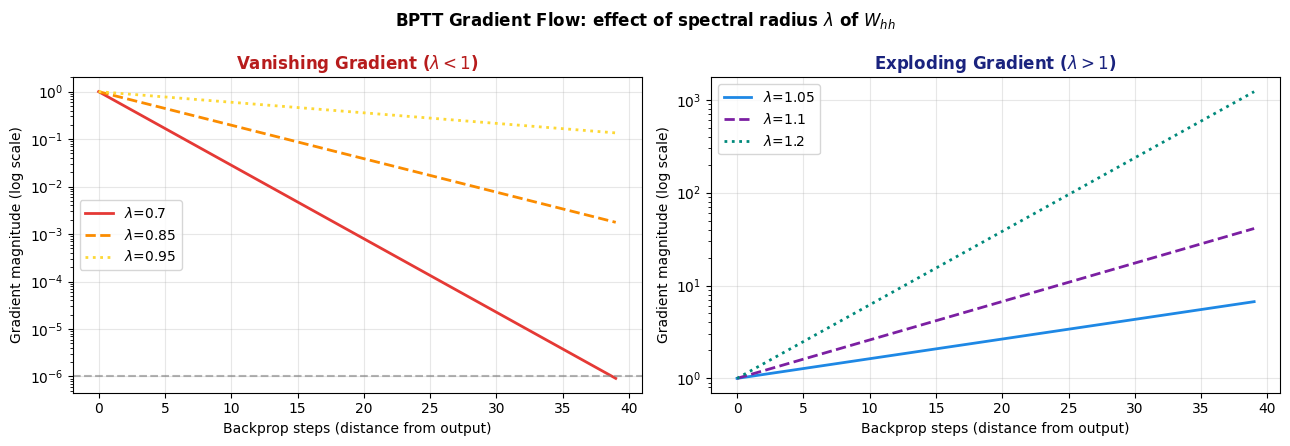

In [17]:
def simulate_gradient(spectral_radius, T=40):
    grad = 1.0
    return [grad * (spectral_radius ** t) for t in range(T)]

T = 40
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Vanishing
for sr, ls, col in [(0.70, '-',  '#E53935'),
                    (0.85, '--', '#FB8C00'),
                    (0.95, ':',  '#FDD835')]:
    ax1.plot(simulate_gradient(sr, T), label=f'$\lambda$={sr}',
             linestyle=ls, linewidth=2, color=col)
ax1.set_yscale('log')
ax1.set_title(r'Vanishing Gradient ($\lambda < 1$)', fontweight='bold', color='#B71C1C')
ax1.set_xlabel('Backprop steps (distance from output)')
ax1.set_ylabel('Gradient magnitude (log scale)')
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)
ax1.axhline(1e-6, color='gray', linestyle='--', alpha=0.6, label='≈ zero threshold')

# Exploding
for sr, ls, col in [(1.05, '-',  '#1E88E5'),
                    (1.10, '--', '#7B1FA2'),
                    (1.20, ':',  '#00897B')]:
    ax2.plot(simulate_gradient(sr, T), label=f'$\lambda$={sr}',
             linestyle=ls, linewidth=2, color=col)
ax2.set_yscale('log')
ax2.set_title(r'Exploding Gradient ($\lambda > 1$)', fontweight='bold', color='#1A237E')
ax2.set_xlabel('Backprop steps (distance from output)')
ax2.set_ylabel('Gradient magnitude (log scale)')
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

plt.suptitle(r'BPTT Gradient Flow: effect of spectral radius $\lambda$ of $W_{hh}$',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


#### 5.2 - Gradient Clipping 

Clipping rescales the gradient vector $g$ whenever $\|g\| > \tau$:

$$g \leftarrow g \cdot \frac{\tau}{\|g\|} \quad \text{if } \|g\| > \tau$$


In [18]:
# Simulate a parameter with a very large gradient (exploding scenario)
param = nn.Parameter(torch.randn(5))
param.grad = torch.tensor([100., -200., 150., -80., 300.])

print(f"Before clipping:")
print(f"  gradient : {param.grad.tolist()}")
print(f"  ‖g‖      : {param.grad.norm().item():.2f}")

nn.utils.clip_grad_norm_([param], max_norm=1.0)

print(f"\nAfter clipping (τ = 1.0):")
print(f"  gradient : {[f'{v:.5f}' for v in param.grad.tolist()]}")
print(f"  ‖g‖      : {param.grad.norm().item():.5f}  <- rescaled to ≤ 1.0")
print("\nDirection is preserved; only magnitude is reduced.")


Before clipping:
  gradient : [100.0, -200.0, 150.0, -80.0, 300.0]
  ‖g‖      : 410.97

After clipping (τ = 1.0):
  gradient : ['0.24332', '-0.48665', '0.36499', '-0.19466', '0.72997']
  ‖g‖      : 1.00000  <- rescaled to ≤ 1.0

Direction is preserved; only magnitude is reduced.


---
## 🔐 Section 6 · LSTM - Gates, Cell State & Gradient Flow

> *"Selective Read, Selective Write, Selective Forget - The Whiteboard Analogy"*

### The four gate equations

Let $\mathbf{z}_t = [h_{t-1};\, x_t]$ (concatenation). Then:

$$\underbrace{f_t}_{\text{forget}} = \sigma\!\left(W_f \mathbf{z}_t + b_f\right)
\qquad
\underbrace{i_t}_{\text{input}}  = \sigma\!\left(W_i \mathbf{z}_t + b_i\right)$$

$$\underbrace{\tilde{C}_t}_{\text{candidate}} = \tanh\!\left(W_g \mathbf{z}_t + b_g\right)
\qquad
\underbrace{o_t}_{\text{output}} = \sigma\!\left(W_o \mathbf{z}_t + b_o\right)$$

### Cell state update & hidden state

$$\boxed{C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t}$$

$$\boxed{h_t = o_t \odot \tanh(C_t)}$$

The cell state $C_t$ flows with **only element-wise operations** (the $\odot$ path).  
No matrix multiplication in the direct gradient path $\Rightarrow$ gradients can flow back many steps  
without exponential decay - this is why LSTM **solves the vanishing gradient problem**.

### Gate roles - Whiteboard analogy

| Gate | Analogy | Range | Role |
|------|---------|-------|------|
| Forget $f_t$ | "Erase" | $(0,1)$ | How much of old cell to **wipe** |
| Input $i_t$ | "Write" | $(0,1)$ | How much new info to **store** |
| Candidate $\tilde{C}_t$ | "New content" | $(-1,1)$ | **What** to potentially write |
| Output $o_t$ | "Read" | $(0,1)$ | What part of cell to **expose** as $h_t$ |


#### 6.1 - LSTM Cell (pure PyTorch)

In [19]:
class LSTMCellManual(nn.Module):
    '''
    Full LSTM cell - all four gates implemented explicitly.
    Matches nn.LSTMCell behaviour exactly.
    '''
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        # Pack all four gate projections into one matrix (standard trick)
        # Order: [forget, input, gate (candidate), output]
        self.W = nn.Linear(input_size + hidden_size, 4 * hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x, state):
        h, C = state
        combined = torch.cat([x, h], dim=1)    # (batch, input + hidden)
        gates    = self.W(combined)            # (batch, 4 * hidden)

        f, i, g, o = gates.chunk(4, dim=1)

        f = torch.sigmoid(f)           # forget gate
        i = torch.sigmoid(i)           # input gate
        g = torch.tanh(g)              # candidate values
        o = torch.sigmoid(o)           # output gate

        C_new = f * C + i * g          # cell state update  <- only ⊙, no matmul!
        h_new = o * torch.tanh(C_new)

        return h_new, C_new, {'forget': f.detach(), 'input': i.detach(),
                               'candidate': g.detach(), 'output': o.detach()}


# ── Instantiate and summarise ─────────────────────────────────
BATCH, INP, HID = 4, 10, 32
lstm_manual = LSTMCellManual(INP, HID).to(DEVICE)

print("=" * 65)
print("torchinfo summary - LSTMCellManual")
print("=" * 65)
# torchinfo needs tensors for multi-input; wrap state as a tuple
x_in  = torch.randn(BATCH, INP,  device=DEVICE)
h_in  = torch.zeros(BATCH, HID,  device=DEVICE)
C_in  = torch.zeros(BATCH, HID,  device=DEVICE)
torchinfo_summary(
    lstm_manual,
    input_data=(x_in, (h_in, C_in)),
    device=DEVICE,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1,
)

h_new, C_new, gate_vals = lstm_manual(x_in, (h_in, C_in))
print("\nGate statistics (mean ± std across batch & units):")
for name, val in gate_vals.items():
    print(f"  {name:10s}: mean={val.mean():.4f}  std={val.std():.4f}")


torchinfo summary - LSTMCellManual
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
LSTMCellManual                           [4, 10]                   [4, 32]                   --                        True
├─Linear: 1-1                            [4, 42]                   [4, 128]                  5,504                     True
Total params: 5,504
Trainable params: 5,504
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.02
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.03

Gate statistics (mean ± std across batch & units):
  forget    : mean=0.5148  std=0.0670
  input     : mean=0.5042  std=0.0697
  candidate : mean=0.0206  std=0.2570
  output    : mean=0.5043  std=0.0809


#### 6.2 - LSTM Hidden State Response to a Sudden Input Change

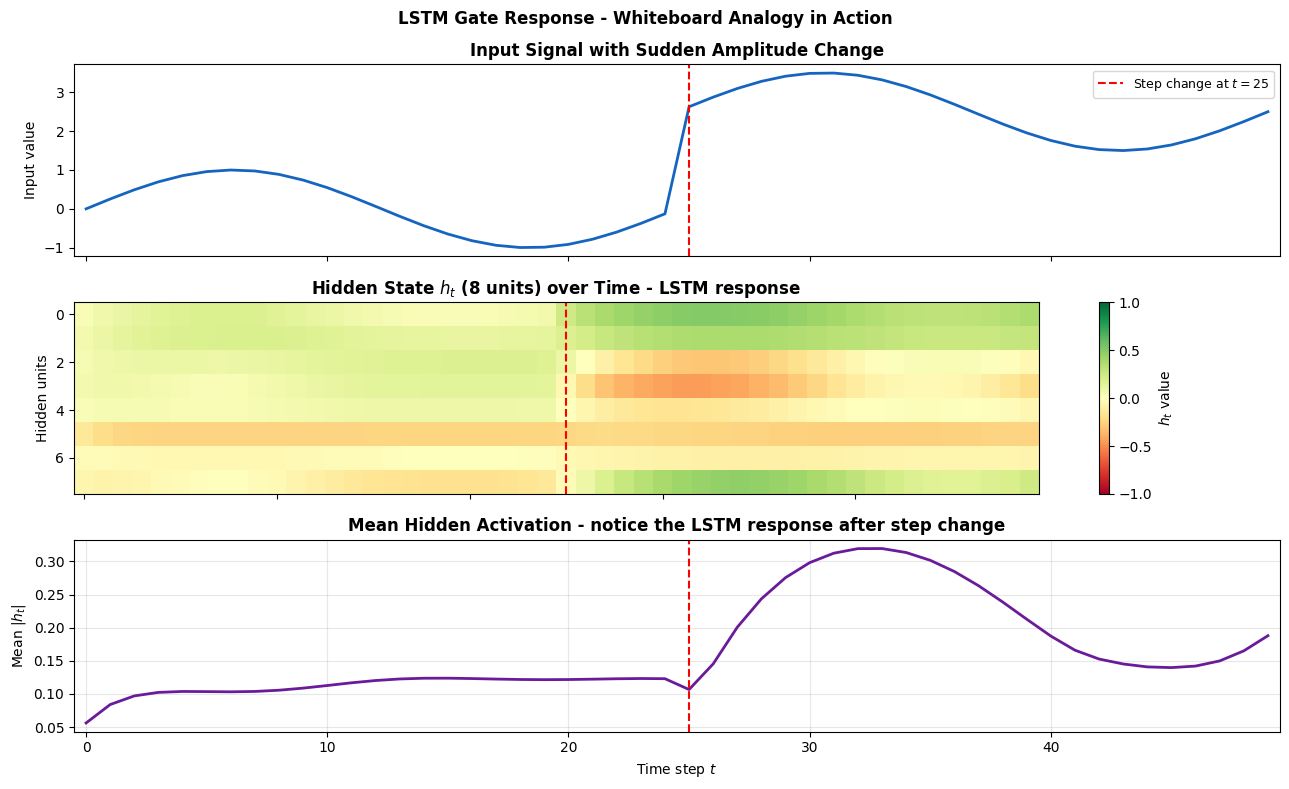

In [20]:
# Synthetic signal: smooth sine -> sudden amplitude step at t=25
T_sig  = 50
t_axis = np.linspace(0, 4 * np.pi, T_sig)
signal = np.sin(t_axis)
signal[25:] += 2.5     # step change - the forget gate should react

x_seq = torch.tensor(signal, dtype=torch.float32, device=DEVICE).unsqueeze(0).unsqueeze(-1)
lstm_layer = nn.LSTM(input_size=1, hidden_size=8, batch_first=True).to(DEVICE)

with torch.no_grad():
    out, (h_f, c_f) = lstm_layer(x_seq)

h_over_time = out.squeeze(0).cpu().numpy()   # (T, 8)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(signal, color='#1565C0', linewidth=2)
axes[0].axvline(25, color='red', linestyle='--', lw=1.5, label='Step change at $t=25$')
axes[0].set_ylabel('Input value', fontsize=10)
axes[0].set_title('Input Signal with Sudden Amplitude Change', fontweight='bold')
axes[0].legend(fontsize=9)

im = axes[1].imshow(h_over_time.T, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].axvline(25, color='red', linestyle='--', lw=1.5)
plt.colorbar(im, ax=axes[1], label=r'$h_t$ value')
axes[1].set_ylabel('Hidden units', fontsize=10)
axes[1].set_title(r'Hidden State $h_t$ (8 units) over Time - LSTM response', fontweight='bold')

axes[2].plot(np.abs(h_over_time).mean(axis=1), linewidth=2, color='#6A1B9A')
axes[2].axvline(25, color='red', linestyle='--', lw=1.5)
axes[2].set_xlabel('Time step $t$', fontsize=10)
axes[2].set_ylabel(r'Mean $|h_t|$', fontsize=10)
axes[2].set_title('Mean Hidden Activation - notice the LSTM response after step change', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('LSTM Gate Response - Whiteboard Analogy in Action', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 📈 Section 7 · Hands-On 2 - Stock Price Prediction with Stacked LSTM

**Dataset:** Apple (AAPL) daily closing prices via `yfinance` (2018 – 2024).  
**Task type:** many $\to$ one (regression) - given the last $T=60$ days, predict day $T+1$.  
**Architecture:** Stacked LSTM (2 layers) $\to$ Dropout $\to$ FC head.

> **⚠️ Disclaimer:** This is a pedagogical exercise in sequence regression.  
> Stock prices are non-stationary and this simple model **cannot** be used for financial decisions.

### Preprocessing pipeline

1. Download raw prices with `yfinance`
2. **Min-Max normalise** to $[0, 1]$: $\tilde{x} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$
3. Create sliding windows of length $T=60$ as input, next day as target
4. Split: 70% train · 15% validation · 15% test (no shuffling - time series!)
5. Inverse-transform predictions to USD for evaluation

### Loss function

Mean squared error in normalised space:

$$\mathcal{L}_{\text{MSE}} = \frac{1}{N}\sum_{i=1}^{N}\left(\hat{y}_i - y_i\right)^2$$


#### 7.1 - Download & Inspect AAPL Data

Records   : 1,760
Date range: 2018-01-02 -> 2024-12-30
Price            Close
Ticker            AAPL
Date                  
2024-12-24  256.560822
2024-12-26  257.375549
2024-12-27  253.967377
2024-12-30  250.598907


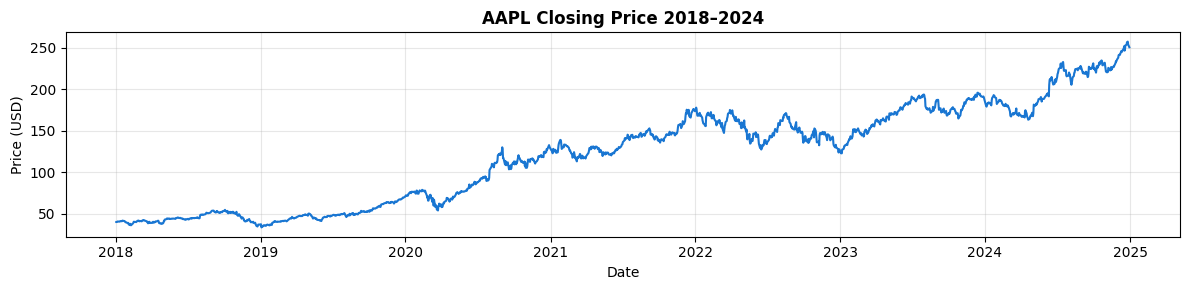

In [21]:
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler

TICKER  = 'AAPL'
SEQ_LEN = 60

print(f"Downloading {TICKER} daily close prices …")
df = yf.download(TICKER, start='2018-01-01', end='2024-12-31',
                 auto_adjust=True, progress=False)
df = df[['Close']].dropna()
print(f"Records   : {len(df):,}")
print(f"Date range: {df.index[0].date()} -> {df.index[-1].date()}")
print(df.tail(4))

plt.figure(figsize=(12, 3))
plt.plot(df.index, df['Close'], linewidth=1.5, color='#1976D2')
plt.title(f'{TICKER} Closing Price 2018–2024', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Price (USD)'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


#### 7.2 - Sliding Window Dataset

In [22]:
scaler = MinMaxScaler(feature_range=(0, 1))
prices_norm = scaler.fit_transform(df['Close'].values.reshape(-1, 1)).flatten()

def make_windows(data, window):
    X = [data[i : i+window]     for i in range(len(data) - window)]
    y = [data[i + window]        for i in range(len(data) - window)]
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = make_windows(prices_norm, SEQ_LEN)
print(f"X shape: {X_all.shape}   y shape: {y_all.shape}")

n      = len(X_all)
n_tr   = int(n * 0.70)
n_val  = int(n * 0.15)

def make_loader(X, y, bs, shuffle):
    Xt = torch.tensor(X).unsqueeze(-1)    # (N, seq, 1)
    yt = torch.tensor(y)
    return DataLoader(TensorDataset(Xt, yt), batch_size=bs,
                      shuffle=shuffle, pin_memory=True)

train_stk = make_loader(X_all[:n_tr],        y_all[:n_tr],        32, True)
val_stk   = make_loader(X_all[n_tr:n_tr+n_val], y_all[n_tr:n_tr+n_val], 32, False)
test_stk  = make_loader(X_all[n_tr+n_val:],  y_all[n_tr+n_val:],  32, False)
print(f"Train: {len(train_stk)} batches  |  Val: {len(val_stk)}  |  Test: {len(test_stk)}")


X shape: (1700, 60)   y shape: (1700,)
Train: 38 batches  |  Val: 8  |  Test: 8


#### 7.3 - Stacked LSTM Model + `torchinfo` Summary

In [23]:
class StockLSTM(nn.Module):
    '''
    Stacked LSTM for univariate time-series regression.
    Architecture:
        LSTM (2 layers, bidirectionality OFF - causal)
        -> Dropout
        -> Linear(hidden -> 32)
        -> ReLU
        -> Linear(32 -> 1)
    '''
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, num_layers,
                               batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden_size, 32)
        self.fc2     = nn.Linear(32, 1)
        self.relu    = nn.ReLU()

    def forward(self, x):
        out, _ = self.lstm(x)
        last    = self.dropout(out[:, -1, :])    # last time step: (batch, hidden)
        return self.fc2(self.relu(self.fc1(last))).squeeze(1)


stock_model = StockLSTM(hidden_size=64, num_layers=2).to(DEVICE)

print("=" * 65)
print("torchinfo summary - StockLSTM")
print("=" * 65)
torchinfo_summary(
    stock_model,
    input_size=(32, SEQ_LEN, 1),
    device=DEVICE,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1,
)


torchinfo summary - StockLSTM
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
StockLSTM                                [32, 60, 1]               [32]                      --                        True
├─LSTM: 1-1                              [32, 60, 1]               [32, 60, 64]              50,432                    True
├─Dropout: 1-2                           [32, 64]                  [32, 64]                  --                        --
├─Linear: 1-3                            [32, 64]                  [32, 32]                  2,080                     True
├─ReLU: 1-4                              [32, 32]                  [32, 32]                  --                        --
├─Linear: 1-5                            [32, 32]                  [32, 1]                   33                        True
Total params: 52,545
Trainable params: 52,545
Non-trainable params: 0
Total mult-adds (Units.MEGABYTE

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
StockLSTM                                [32, 60, 1]               [32]                      --                        True
├─LSTM: 1-1                              [32, 60, 1]               [32, 60, 64]              50,432                    True
├─Dropout: 1-2                           [32, 64]                  [32, 64]                  --                        --
├─Linear: 1-3                            [32, 64]                  [32, 32]                  2,080                     True
├─ReLU: 1-4                              [32, 32]                  [32, 32]                  --                        --
├─Linear: 1-5                            [32, 32]                  [32, 1]                   33                        True
Total params: 52,545
Trainable params: 52,545
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 96.90
Input size (MB): 0.0

#### 7.4 - Train & Validate

In [25]:
STOCK_EPOCHS = 30
crit_mse   = nn.MSELoss()
opt_stk    = optim.Adam(stock_model.parameters(), lr=1e-3, weight_decay=1e-5)
sched_stk  = optim.lr_scheduler.ReduceLROnPlateau(
    opt_stk,
    patience=3,
    factor=0.5
)
best_val   = float('inf')
stk_hist   = {'train_loss': [], 'val_loss': []}

for epoch in range(1, STOCK_EPOCHS + 1):
    stock_model.train()
    t_loss = 0.0
    for xb, yb in train_stk:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_stk.zero_grad()
        pred  = stock_model(xb)
        loss  = crit_mse(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(stock_model.parameters(), 1.0)
        opt_stk.step()
        t_loss += loss.item()

    stock_model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_stk:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            v_loss += crit_mse(stock_model(xb), yb).item()

    t_loss /= len(train_stk);  v_loss /= len(val_stk)
    stk_hist['train_loss'].append(t_loss)
    stk_hist['val_loss'].append(v_loss)
    sched_stk.step(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        torch.save(stock_model.state_dict(), '/tmp/best_stock_lstm.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{STOCK_EPOCHS}  "
              f"Train MSE: {t_loss:.6f}  Val MSE: {v_loss:.6f}")

print(f"\nBest validation MSE: {best_val:.6f}")


Epoch   1/30  Train MSE: 0.067805  Val MSE: 0.087122
Epoch   5/30  Train MSE: 0.001565  Val MSE: 0.000714
Epoch  10/30  Train MSE: 0.001271  Val MSE: 0.000871
Epoch  15/30  Train MSE: 0.001212  Val MSE: 0.000642
Epoch  20/30  Train MSE: 0.001070  Val MSE: 0.001057
Epoch  25/30  Train MSE: 0.001043  Val MSE: 0.001000
Epoch  30/30  Train MSE: 0.001094  Val MSE: 0.000998

Best validation MSE: 0.000542


#### 7.5 - Test Set Evaluation & Prediction Plot

Test RMSE : $10.88
Test MAE  : $8.88


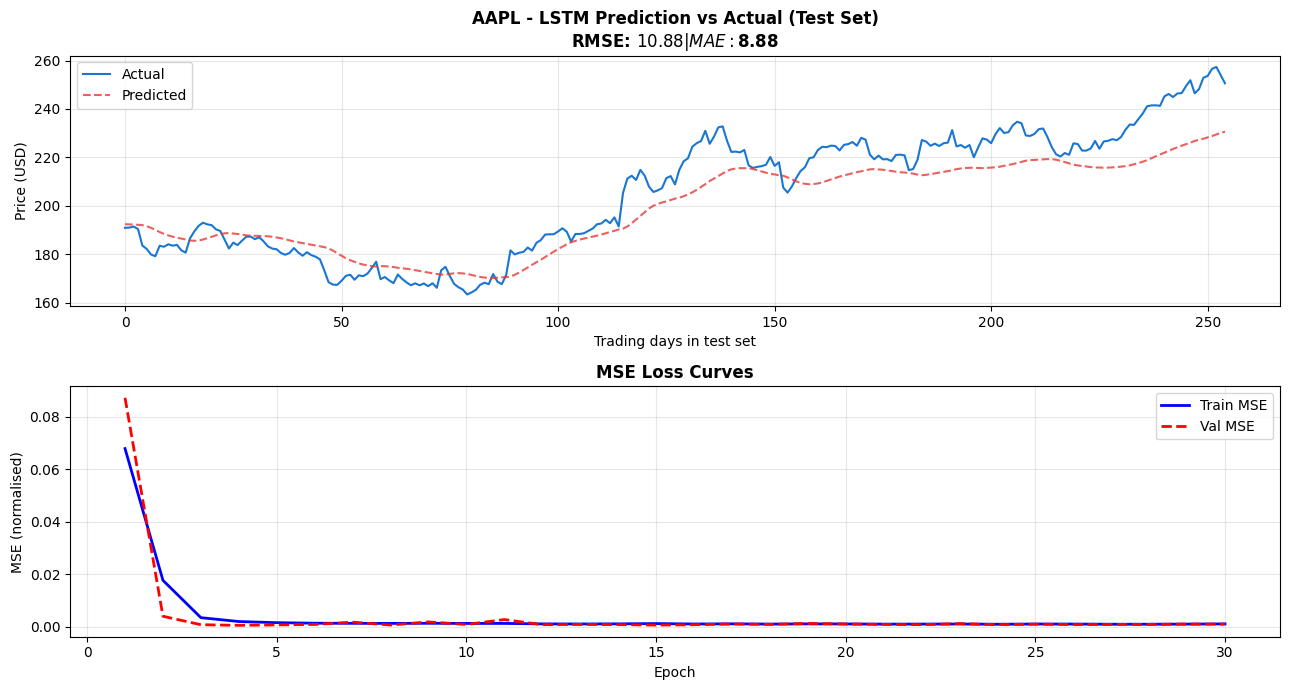

In [26]:
stock_model.load_state_dict(torch.load('/tmp/best_stock_lstm.pt', map_location=DEVICE))
stock_model.eval()

preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_stk:
        preds.extend(stock_model(xb.to(DEVICE)).cpu().numpy())
        trues.extend(yb.numpy())

preds_usd = scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
trues_usd = scaler.inverse_transform(np.array(trues).reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((preds_usd - trues_usd)**2))
mae  = np.mean(np.abs(preds_usd - trues_usd))
print(f"Test RMSE : ${rmse:.2f}")
print(f"Test MAE  : ${mae:.2f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))

ax1.plot(trues_usd,  linewidth=1.5, label='Actual',    color='#1976D2')
ax1.plot(preds_usd,  linewidth=1.5, label='Predicted', color='#E53935', alpha=0.8, linestyle='--')
ax1.set_title(f'{TICKER} - LSTM Prediction vs Actual (Test Set)\nRMSE: ${rmse:.2f}  |  MAE: ${mae:.2f}',
              fontweight='bold')
ax1.set_xlabel('Trading days in test set'); ax1.set_ylabel('Price (USD)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ep_r = range(1, STOCK_EPOCHS + 1)
ax2.plot(ep_r, stk_hist['train_loss'], 'b-', label='Train MSE',  linewidth=2)
ax2.plot(ep_r, stk_hist['val_loss'],   'r--', label='Val MSE',   linewidth=2)
ax2.set_title('MSE Loss Curves', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE (normalised)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


---
## ⚡ Section 8 · GRU - Simpler but Powerful

> *"Proposed in 2014 as a simpler alternative to LSTM"* - Cho et al.

### GRU equations

$$\underbrace{z_t}_{\text{update gate}} = \sigma\!\left(W_z [h_{t-1};\, x_t]\right)$$

$$\underbrace{r_t}_{\text{reset gate}}  = \sigma\!\left(W_r [h_{t-1};\, x_t]\right)$$

$$\tilde{h}_t = \tanh\!\left(W_h [r_t \odot h_{t-1};\, x_t]\right)  \quad \text{(candidate)}$$

$$\boxed{h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t}$$

- **Update gate** $z_t$: interpolates between old state $h_{t-1}$ and new candidate $\tilde{h}_t$.  
  When $z_t \approx 0$ -> keep old state (long-term memory preserved).  
  When $z_t \approx 1$ -> replace with new content (quick adaptation).

- **Reset gate** $r_t$: controls how much of $h_{t-1}$ influences the candidate.  
  When $r_t \approx 0$ -> ignore previous state (useful at the start of a new topic).

### GRU vs LSTM comparison

| Property | LSTM | GRU |
|----------|------|-----|
| Gates | 4 ($f, i, \tilde{C}, o$) | 2 ($z, r$) |
| Internal state | $h_t + C_t$ (two vectors) | $h_t$ only (one vector) |
| Parameters (same hidden size) | $\sim 4 \times (d+h) \times h$ | $\sim 3 \times (d+h) \times h$ |
| Speed | Slower | ~25–33% faster |
| Best for | Long sequences, large data | Speech, NLP, resource-constrained |


#### 8.1 - Parameter Count & Speed Benchmark (RNN vs GRU vs LSTM)

In [27]:
import time

BENCH_CONFIGS = {
    'Vanilla RNN': nn.RNN,
    'GRU'        : nn.GRU,
    'LSTM'       : nn.LSTM,
}
INP_B, HID_B, SEQ_B, BSZ_B, REPS = 128, 256, 50, 32, 200

print(f"{'Model':<15} {'Parameters':>14} {'ms / forward':>14}")
print("─" * 46)
for name, cls in BENCH_CONFIGS.items():
    m = cls(input_size=INP_B, hidden_size=HID_B, batch_first=True).to(DEVICE)
    n = sum(p.numel() for p in m.parameters())
    x = torch.randn(BSZ_B, SEQ_B, INP_B, device=DEVICE)

    # warm-up
    with torch.no_grad():
        for _ in range(20): m(x)

    if DEVICE.type == 'cuda': torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(REPS): m(x)
    if DEVICE.type == 'cuda': torch.cuda.synchronize()
    ms = (time.perf_counter() - t0) / REPS * 1000
    print(f"{name:<15} {n:>14,} {ms:>13.2f}")


Model               Parameters   ms / forward
──────────────────────────────────────────────
Vanilla RNN             98,816          0.68
GRU                    296,448          1.16
LSTM                   395,264          0.93


#### 8.2 - Bidirectional GRU Sentiment Model + `torchinfo`

In [28]:
class SentimentGRU(nn.Module):
    '''
    Bidirectional 2-layer GRU for sentiment classification.
    Concatenates the last forward and backward hidden states -> fc -> logit.
    '''
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru       = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                                batch_first=True, bidirectional=True,
                                dropout=dropout if n_layers > 1 else 0.0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, 1)   # ×2 for bidirectional

    def forward(self, x):
        emb  = self.dropout(self.embedding(x))
        _, h = self.gru(emb)         # h: (2 * n_layers, batch, hidden)
        h_fwd = h[-2]                # last layer, forward direction
        h_bwd = h[-1]                # last layer, backward direction
        h_cat = self.dropout(torch.cat([h_fwd, h_bwd], dim=1))
        return self.fc(h_cat).squeeze(1)


gru_model = SentimentGRU(len(word2idx), EMBED_DIM, HIDDEN_DIM, n_layers=2).to(DEVICE)

print("=" * 65)
print("torchinfo summary - SentimentGRU (Bidirectional, 2 layers)")
print("=" * 65)
torchinfo_summary(
    gru_model,
    input_size=(BATCH_SIZE, MAX_LEN),
    dtypes=[torch.long],
    device=DEVICE,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1,
)

n_rnn = sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)
n_gru = sum(p.numel() for p in gru_model.parameters() if p.requires_grad)
print(f"\nVanilla RNN (1-layer)         : {n_rnn:>8,} params")
print(f"Bidirectional GRU (2-layer)   : {n_gru:>8,} params")


torchinfo summary - SentimentGRU (Bidirectional, 2 layers)
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
SentimentGRU                             [128, 200]                [128]                     --                        True
├─Embedding: 1-1                         [128, 200]                [128, 200, 64]            640,000                   True
├─Dropout: 1-2                           [128, 200, 64]            [128, 200, 64]            --                        --
├─GRU: 1-3                               [128, 200, 64]            [128, 200, 256]           445,440                   True
├─Dropout: 1-4                           [128, 256]                [128, 256]                --                        --
├─Linear: 1-5                            [128, 256]                [128, 1]                  257                       True
Total params: 1,085,697
Trainable params: 1,085,697
Non-trainable params

---
## 🔭 Section 9 · Sequence-to-Sequence + Attention (Encoder-Decoder)

> *"English: the black cat drank milk (5 words) -> French: le chat noir a bu du lait (7 words)"*

### Encoder-Decoder Architecture

$$\underbrace{x_1, x_2, \ldots, x_S}_{\text{source}} \xrightarrow{\text{Encoder LSTM}} \mathbf{h}^{\text{enc}}_{1:S}
\xrightarrow{\text{Attention}} c_t \xrightarrow{\text{Decoder LSTM}} \underbrace{y_1, y_2, \ldots, y_T}_{\text{target}}$$

### Why plain Encoder-Decoder fails for long sequences

The entire source sentence is compressed into a **single vector** $h_S$.  
For long sentences, information from early tokens is lost.

### Bahdanau (Additive) Attention - solution

At each decoder step $t$, compute a **context vector** $c_t$ as a weighted sum of **all** encoder hidden states:

$$e_{t,s} = v^{\top} \tanh\!\left(W_a\, h^{\text{dec}}_{t-1} + U_a\, h^{\text{enc}}_s\right)$$

$$\alpha_{t,s} = \frac{\exp(e_{t,s})}{\sum_{s'} \exp(e_{t,s'})} \quad \text{(softmax)}$$

$$c_t = \sum_{s=1}^{S} \alpha_{t,s}\, h^{\text{enc}}_s$$

$\alpha_{t,s}$ is the **attention weight**: how much decoder step $t$ should focus on encoder position $s$.  
The matrix $[\alpha_{t,s}]_{t,s}$ is called the **attention map** - it is directly interpretable.


#### 9.1 - Bahdanau Attention Module + Attention Map Visualisation

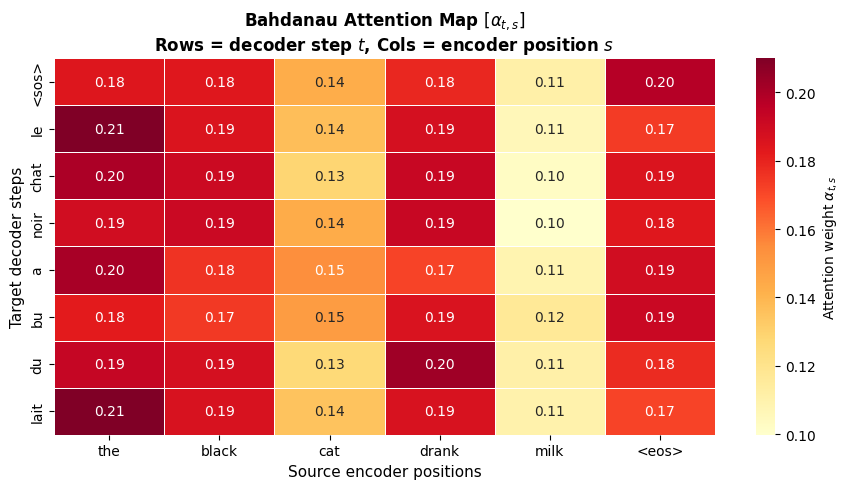

Higher cell value -> decoder pays more attention to that source position.
In a trained model, 'chat' would strongly attend to 'cat', etc.


In [30]:
class BahdanauAttention(nn.Module):
    '''Additive attention (Bahdanau et al., 2015).'''
    def __init__(self, enc_hid: int, dec_hid: int):
        super().__init__()
        self.W_a = nn.Linear(dec_hid, dec_hid, bias=False)
        self.U_a = nn.Linear(enc_hid, dec_hid, bias=False)
        self.v   = nn.Linear(dec_hid, 1,       bias=False)

    def forward(self, h_dec, enc_outputs):
        '''
        h_dec       : (batch, dec_hid)
        enc_outputs : (batch, src_len, enc_hid)
        returns
            context : (batch, enc_hid)
            weights : (batch, src_len)
        '''
        src_len = enc_outputs.size(1)
        # Broadcast decoder state over all encoder positions
        h_dec_exp = self.W_a(h_dec).unsqueeze(1).expand(-1, src_len, -1)   # (B, S, dec_hid)
        energy    = torch.tanh(h_dec_exp + self.U_a(enc_outputs))           # (B, S, dec_hid)
        scores    = self.v(energy).squeeze(-1)                               # (B, S)
        weights   = torch.softmax(scores, dim=1)                             # (B, S)
        context   = torch.bmm(weights.unsqueeze(1), enc_outputs).squeeze(1) # (B, enc_hid)
        return context, weights


# ── Visualise attention map on a toy English->French pair ─────
ENC_HID, DEC_HID = 64, 64
SRC_TOKENS = ['the', 'black', 'cat', 'drank', 'milk', '<eos>']
TGT_TOKENS = ['<sos>', 'le', 'chat', 'noir', 'a', 'bu', 'du', 'lait']

SRC_LEN, TGT_LEN = len(SRC_TOKENS), len(TGT_TOKENS)

attn_module  = BahdanauAttention(ENC_HID, DEC_HID).to(DEVICE)
enc_out_fake = torch.randn(1, SRC_LEN, ENC_HID, device=DEVICE)

attn_matrix = []
h_dec = torch.randn(1, DEC_HID, device=DEVICE)
for _ in range(TGT_LEN):
    ctx, w = attn_module(h_dec, enc_out_fake)
    attn_matrix.append(w.squeeze(0).detach().cpu().numpy())
    h_dec = torch.randn(1, DEC_HID, device=DEVICE)   # next decoder state (simulated)

attn_matrix = np.array(attn_matrix)   # (TGT_LEN, SRC_LEN)

plt.figure(figsize=(9, 5))

sns.heatmap(
    attn_matrix,
    xticklabels=SRC_TOKENS,
    yticklabels=TGT_TOKENS,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': r'Attention weight $\alpha_{t,s}$'}
)

plt.title(
    r'Bahdanau Attention Map $[\alpha_{t,s}]$' + '\n'
    r'Rows = decoder step $t$, Cols = encoder position $s$',
    fontweight='bold'
)

plt.xlabel('Source encoder positions', fontsize=11)
plt.ylabel('Target decoder steps', fontsize=11)
plt.tight_layout()
plt.show()

print("Higher cell value -> decoder pays more attention to that source position.")
print("In a trained model, 'chat' would strongly attend to 'cat', etc.")


#### 9.2 - `torchinfo` Summary of Attention Module

In [31]:
print("=" * 65)
print("torchinfo summary - BahdanauAttention")
print("=" * 65)
torchinfo_summary(
    attn_module,
    input_data=(torch.randn(1, DEC_HID, device=DEVICE),
                torch.randn(1, SRC_LEN, ENC_HID, device=DEVICE)),
    device=DEVICE,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1,
)


torchinfo summary - BahdanauAttention
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BahdanauAttention                        [1, 64]                   [1, 64]                   --                        True
├─Linear: 1-1                            [1, 64]                   [1, 64]                   4,096                     True
├─Linear: 1-2                            [1, 6, 64]                [1, 6, 64]                4,096                     True
├─Linear: 1-3                            [1, 6, 64]                [1, 6, 1]                 64                        True
Total params: 8,256
Trainable params: 8,256
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.03
Estimated Total Size (MB): 0.04


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
BahdanauAttention                        [1, 64]                   [1, 64]                   --                        True
├─Linear: 1-1                            [1, 64]                   [1, 64]                   4,096                     True
├─Linear: 1-2                            [1, 6, 64]                [1, 6, 64]                4,096                     True
├─Linear: 1-3                            [1, 6, 64]                [1, 6, 1]                 64                        True
Total params: 8,256
Trainable params: 8,256
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.03
Estimated Total Size (MB): 0.04

---
## ✍️ Section 10 · Hands-On 3 - Character-Level Text Generation with LSTM (Shakespeare)

**Dataset:** Shakespeare's complete works (public domain, ~1 MB of text).  
**Task type:** one $\to$ many - given a seed string, generate new Shakespearean text.  
**Architecture:** Embedding $\to$ Stacked LSTM $\to$ Linear $\to$ Softmax over characters.

This is a **character-level language model** - a direct implementation of the language-model slide  
showing *"dog -> playing -> ball -> \<eos\>"*.

### Language model objective

At each step the model predicts the **next character** given all previous characters:

$$\mathcal{L} = -\sum_{t=1}^{T} \log P\!\left(c_t \mid c_1, c_2, \ldots, c_{t-1}\right)$$

This is cross-entropy loss over the vocabulary of characters ($|\mathcal{V}| \approx 65$).

### Temperature sampling

Instead of always picking $\arg\max$, we sample from a **temperature-scaled softmax**:

$$P(c) = \frac{\exp(z_c / \tau)}{\sum_{c'} \exp(z_{c'} / \tau)}$$

| Temperature $\tau$ | Effect |
|---|---|
| $\tau \ll 1$ (e.g. 0.3) | Confident, repetitive - "peaked" distribution |
| $\tau = 1.0$ | Standard softmax |
| $\tau \gg 1$ (e.g. 1.5) | Creative, more random - "flat" distribution |


#### 10.1 - Download Shakespeare Text

In [32]:
import urllib.request

SHAK_PATH = '/tmp/shakespeare.txt'
if not os.path.exists(SHAK_PATH):
    print("Downloading Shakespeare corpus …")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
        SHAK_PATH)
    print("Done.")

with open(SHAK_PATH, 'r') as f:
    corpus = f.read()

print(f"Total characters : {len(corpus):,}")
print(f"Unique characters: {len(set(corpus))}")
print(f"\nFirst 250 chars:\n{corpus[:250]}")


Done.
Total characters : 1,115,394
Unique characters: 65

First 250 chars:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



#### 10.2 - Build Character Vocabulary & Sliding-Window Dataset

In [33]:
CHARS   = sorted(set(corpus))
VOCAB_C = len(CHARS)
ch2id   = {c: i for i, c in enumerate(CHARS)}
id2ch   = {i: c for c, i in ch2id.items()}

print(f"Vocab size: {VOCAB_C}")
print(f"Characters: {''.join(CHARS[:30])} …")

SEQ_SHAK = 100    # input sequence length
STEP     = 25     # stride for sliding window

X_shak, y_shak = [], []
for i in range(0, len(corpus) - SEQ_SHAK - 1, STEP):
    X_shak.append([ch2id[c] for c in corpus[i      : i + SEQ_SHAK]])
    y_shak.append([ch2id[c] for c in corpus[i + 1  : i + SEQ_SHAK + 1]])

X_shak = torch.tensor(X_shak, dtype=torch.long)
y_shak = torch.tensor(y_shak, dtype=torch.long)
print(f"\nSequences: {len(X_shak):,}   X: {X_shak.shape}   y: {y_shak.shape}")

shak_ldr = DataLoader(TensorDataset(X_shak, y_shak),
                      batch_size=128, shuffle=True, pin_memory=True)


Vocab size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQ …

Sequences: 44,612   X: torch.Size([44612, 100])   y: torch.Size([44612, 100])


#### 10.3 - Character LSTM Model + `torchinfo`

In [34]:
class CharLSTM(nn.Module):
    '''
    Character-level language model.
    Architecture:
        Embedding(vocab, embed_dim)
        -> LSTM (n_layers, hidden_size)
        -> Dropout
        -> Linear(hidden_size, vocab)  <- one logit per character
    '''
    def __init__(self, vocab_size, embed_dim=64, hidden_size=256,
                 n_layers=2, dropout=0.3):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_dim)
        self.lstm    = nn.LSTM(embed_dim, hidden_size, n_layers,
                               batch_first=True, dropout=dropout)
        self.drop    = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, vocab_size)
        self.n_layers  = n_layers
        self.h_size    = hidden_size

    def forward(self, x, state=None):
        emb         = self.drop(self.embed(x))        # (B, T, embed)
        out, state  = self.lstm(emb, state)            # out: (B, T, hidden)
        logits      = self.fc(self.drop(out))          # (B, T, vocab)
        return logits, state

    def init_state(self, batch_size, device):
        h = torch.zeros(self.n_layers, batch_size, self.h_size, device=device)
        c = torch.zeros(self.n_layers, batch_size, self.h_size, device=device)
        return h, c


char_model = CharLSTM(VOCAB_C, embed_dim=64, hidden_size=256, n_layers=2).to(DEVICE)

print("=" * 65)
print("torchinfo summary - CharLSTM")
print("=" * 65)
torchinfo_summary(
    char_model,
    input_size=(128, SEQ_SHAK),
    dtypes=[torch.long],
    device=DEVICE,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1,
)


torchinfo summary - CharLSTM
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
CharLSTM                                 [128, 100]                [128, 100, 65]            --                        True
├─Embedding: 1-1                         [128, 100]                [128, 100, 64]            4,160                     True
├─Dropout: 1-2                           [128, 100, 64]            [128, 100, 64]            --                        --
├─LSTM: 1-3                              [128, 100, 64]            [128, 100, 256]           856,064                   True
├─Dropout: 1-4                           [128, 100, 256]           [128, 100, 256]           --                        --
├─Linear: 1-5                            [128, 100, 256]           [128, 100, 65]            16,705                    True
Total params: 876,929
Trainable params: 876,929
Non-trainable params: 0
Total mult-adds (Units.GIGABYT

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
CharLSTM                                 [128, 100]                [128, 100, 65]            --                        True
├─Embedding: 1-1                         [128, 100]                [128, 100, 64]            4,160                     True
├─Dropout: 1-2                           [128, 100, 64]            [128, 100, 64]            --                        --
├─LSTM: 1-3                              [128, 100, 64]            [128, 100, 256]           856,064                   True
├─Dropout: 1-4                           [128, 100, 256]           [128, 100, 256]           --                        --
├─Linear: 1-5                            [128, 100, 256]           [128, 100, 65]            16,705                    True
Total params: 876,929
Trainable params: 876,929
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 10.96
Input size (MB): 0

#### 10.4 - Training the Character Language Model

Training character-level LSTM on Shakespeare …

Epoch  1/10  Loss: 2.1906  Perplexity: 8.9
Epoch  2/10  Loss: 1.6882  Perplexity: 5.4
Epoch  3/10  Loss: 1.5759  Perplexity: 4.8
Epoch  4/10  Loss: 1.5194  Perplexity: 4.6
Epoch  5/10  Loss: 1.4848  Perplexity: 4.4
Epoch  6/10  Loss: 1.4619  Perplexity: 4.3
Epoch  7/10  Loss: 1.4461  Perplexity: 4.2
Epoch  8/10  Loss: 1.4354  Perplexity: 4.2
Epoch  9/10  Loss: 1.4290  Perplexity: 4.2
Epoch 10/10  Loss: 1.4260  Perplexity: 4.2


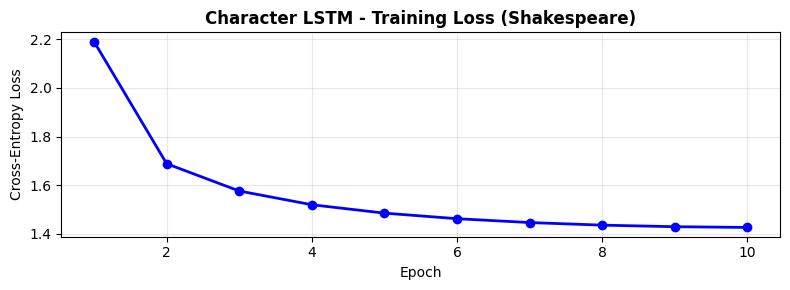

In [35]:
SHAK_EPOCHS = 10
crit_ce   = nn.CrossEntropyLoss()
opt_shak  = optim.Adam(char_model.parameters(), lr=2e-3)
sched_shk = optim.lr_scheduler.CosineAnnealingLR(opt_shak, T_max=SHAK_EPOCHS)

shak_losses = []
print("Training character-level LSTM on Shakespeare …\n")

for epoch in range(1, SHAK_EPOCHS + 1):
    char_model.train()
    ep_loss = 0.0
    for xb, yb in shak_ldr:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt_shak.zero_grad()
        logits, _ = char_model(xb)                             # (B, T, vocab)
        loss      = crit_ce(logits.reshape(-1, VOCAB_C), yb.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(char_model.parameters(), 1.0)
        opt_shak.step()
        ep_loss += loss.item()

    sched_shk.step()
    avg_loss   = ep_loss / len(shak_ldr)
    perplexity = np.exp(avg_loss)
    shak_losses.append(avg_loss)
    print(f"Epoch {epoch:2d}/{SHAK_EPOCHS}  "
          f"Loss: {avg_loss:.4f}  Perplexity: {perplexity:.1f}")

plt.figure(figsize=(8, 3))
plt.plot(range(1, SHAK_EPOCHS+1), shak_losses, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.title('Character LSTM - Training Loss (Shakespeare)', fontweight='bold')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


#### 10.5 - Text Generation with Temperature Sampling

Sample from the temperature-scaled distribution:

$$P(c_t \mid c_{<t}) \propto \exp\!\left(\frac{z_{c_t}}{\tau}\right)$$


In [36]:
def generate_text(model, seed: str, length: int = 250,
                  temperature: float = 0.8, device=DEVICE):
    model.eval()
    output = list(seed)
    state  = model.init_state(1, device)

    # Feed the seed into the model to build up state
    for ch in seed:
        x = torch.tensor([[ch2id[ch]]], dtype=torch.long, device=device)
        with torch.no_grad():
            _, state = model(x, state)

    current = seed[-1]
    for _ in range(length):
        x = torch.tensor([[ch2id[current]]], dtype=torch.long, device=device)
        with torch.no_grad():
            logits, state = model(x, state)              # (1, 1, vocab)
        probs   = torch.softmax(logits.squeeze() / temperature, dim=0)
        idx     = torch.multinomial(probs, 1).item()
        current = id2ch[idx]
        output.append(current)

    return ''.join(output)


for seed in ["ROMEO:", "HAMLET:", "FIRST CITIZEN:"]:
    print("=" * 55)
    print(f"Seed: '{seed}'   (temperature=0.7)")
    print("-" * 55)
    print(generate_text(char_model, seed, length=200, temperature=0.7))
    print()


Seed: 'ROMEO:'   (temperature=0.7)
-------------------------------------------------------
ROMEO:
The love were never boar can speak and sweet duke thou;
And I have allience and fawn to other immortal.

LADY CAPULET:
Ay, and my lord, as thou time.

CLARENCE:
No more to shall see the foal life in 

Seed: 'HAMLET:'   (temperature=0.7)
-------------------------------------------------------
HAMLET:
What brother's mother is my brother send
To some water from my grace of his person;
And the soul is bastard to the majesty,
To so hope in thine in bloody crown;
And, I would the great bounds and here

Seed: 'FIRST CITIZEN:'   (temperature=0.7)
-------------------------------------------------------
FIRST CITIZEN:
I will be king is dust can will proud your voice,
And to the uffects and him the news:
But I think you are so him.

First Gentleman:
Now I did so then him in the single true
Than an officers will cro



#### 10.6 - Effect of Temperature on Generated Text

Compare low $\tau$ (confident) vs high $\tau$ (creative):


In [37]:
seed = "OTHELLO:"
print(f"Seed: '{seed}'\n")
for tau in [0.3, 0.7, 1.0, 1.5]:
    print(f"─── Temperature τ = {tau} ─────────────────────────")
    print(generate_text(char_model, seed, length=120, temperature=tau))
    print()


Seed: 'OTHELLO:'

─── Temperature τ = 0.3 ─────────────────────────
OTHELLO:
The world so should be the strength of his son.

DUKE VINCENTIO:
I will be so for the father's house,
To the man of the

─── Temperature τ = 0.7 ─────────────────────────
OTHELLO:
I have the shadows, our hearts to a senses now,
And never will be our sea for thee here.

KING RICHARD III:
When what t

─── Temperature τ = 1.0 ─────────────────────────
OTHELLO: I have care with ulsister, these prithee wounds.
O vintuous rose sould can, that I know
'Tis baids, what please that wa

─── Temperature τ = 1.5 ─────────────────────────
OTHELLO:
Then 'noud a-your,
Do not; and interact to A-horn wirmes, creature;
Did bignor you, talk in grief;
Let them: behrinkly 



---
## 🏆 Section 11 · Tasks

> Complete these after the workshop using this notebook as your starting point.

---

### 📝 Task 1 - Upgrade the Sentiment Classifier 

**Objective:** Replace the Vanilla RNN in Section 4 with LSTM or GRU and measure the improvement.

**Steps:**

1. Copy `SentimentRNN` from Section 4 and rename it `SentimentLSTM`.
2. Replace `nn.RNN(...)` with `nn.LSTM(...)` (set `bidirectional=True`, `num_layers=2`).
3. Adjust the `h_last` extraction - for a bidirectional LSTM:  
   $h_{\text{final}} = [h_{\text{forward}, -1}\, ;\, h_{\text{backward}, -1}]$  
   so `nn.Linear` input size becomes `hidden_dim * 2`.
4. Print the `torchinfo` summary for your new model.
5. Re-train with the same hyperparameters as Section 4.

**Deliverables:**

| | Vanilla RNN | Your LSTM/GRU |
|--|--|--|
| Params | ? | ? |
| Val Accuracy (%) | ? | ? |
| Test Accuracy (%) | ? | ? |

- Training curve plot (both models overlaid)
- Written answer (2–3 sentences): *Why does LSTM/GRU outperform Vanilla RNN on IMDB?*

**Target:** test accuracy $\geq 85\%$ with LSTM/GRU.

---

### 📝 Task 2 - Character-Level Name Generator with GRU 
**Objective:** Build a character-level GRU that generates realistic names from a chosen culture.

**Steps:**

1. Find a public names dataset (e.g. search "names dataset" on Kaggle, pick any language with $\geq 2000$ names).
2. Adapt `CharLSTM` from Section 10 to use `nn.GRU` instead of `nn.LSTM`.  
   Note: GRU has no cell state $C_t$, so `init_state` returns only $h_0$ (not $(h_0, c_0)$).
3. Train for at least 15 epochs.
4. Generate 20 names at temperature $\tau = 0.6$ and 20 at $\tau = 1.2$.
5. Print the `torchinfo` summary of your GRU model.

**Deliverables:**

- Working notebook with GRU model and `torchinfo` summary
- Training loss curve
- 40 generated names (20 per temperature)
- Written answer (1 paragraph): *How does temperature $\tau$ affect the creativity and coherence of the generated names?*


---


---
## 📚 Takeaways

| Concept | Core Formula | Insight |
|---------|-------------|---------|
| RNN recurrence | $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$ | Same weights every step - parameter sharing |
| BPTT gradient | $\prod_{j} W_{hh}^{\top} \operatorname{diag}(1 - h_j^2)$ | Repeated product causes vanishing/exploding |
| Gradient clipping | $g \leftarrow g \cdot \frac{\tau}{\|g\|}$ | Caps gradient norm - prevents explosion |
| LSTM cell update | $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$ | Element-wise path -> gradient flows freely |
| GRU hidden | $h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$ | Single state, two gates - faster, simpler |
| Attention | $c_t = \sum_s \alpha_{t,s} h^{\text{enc}}_s$ | Decoder sees all encoder states - no bottleneck |
| Temperature | $P(c) \propto \exp(z_c / \tau)$ | $\tau < 1$ focused, $\tau > 1$ creative |

---

### Verified References

- **Hochreiter & Schmidhuber (1997).** *Long Short-Term Memory.* Neural Computation, 9(8), 1735–1780.
- **Cho et al. (2014).** *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation.* EMNLP. (introduces GRU)
- **Bahdanau et al. (2015).** *Neural Machine Translation by Jointly Learning to Align and Translate.* ICLR.
- **Karpathy (2015).** *The Unreasonable Effectiveness of Recurrent Neural Networks.* `karpathy.github.io/2015/05/21/rnn-effectiveness/`

---

<div align="center">
  <h3>🎓 Thank you! Questions? </h3>
  <p>Amity Centre for Artificial Intelligence · Amity University Noida · June 2026</p>
</div>
